# Bloomberg PORT MAC 3 — Python Companion Notebook (USE4-Grounded)

Implements every concept from the technical PDF, grounded in the USE4 methodology
(Menchero, Orr & Wang, 2011). Each section corresponds to the PDF section.

**Contents:**
1. Linear Factor Model Basics
2. Cross-Sectional Regression — OLS + Country Factor Constraint
3. Factor Exposure Quality (Stability, VIF, Standardisation, Multiple-Industry)
4. Duration Times Spread (DTS) for HY Bonds
5. Factor Covariance Matrix — EWMA, Eigenfactor Adjustment, VRA
6. Specific Risk — Bayesian Shrinkage
7. Bias Statistics (USE4 Appendix A)
8. Portfolio Risk Attribution


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import linalg
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
print("Setup complete.")


Setup complete.


## 1. Linear Factor Model: First Principles (USE4 §1.3)

**Model:** r = X f + u
- X: N×K factor exposure matrix (observable fundamentals)
- f: K×1 factor returns (estimated by CSR)
- u: N×1 specific returns (idiosyncratic)

**Portfolio variance (USE4 Eq. 1.5):** Var(R_P) = b'Fb + w'Δw
where b = X'w (portfolio factor exposures), F = factor covariance matrix, Δ = diagonal specific variance.


In [2]:
# Five assets, three factors: Market, Size, Value
N, K = 5, 3
factor_names = ["Market", "Size", "Value"]
asset_names  = ["Apple", "Goldman", "Ford", "IBM", "JPMorgan"]

# Factor exposure matrix X (N x K)
X = np.array([
    [1.0,  1.32, -0.54],   # Apple:    large-cap tech, negative value
    [1.0,  1.18,  0.34],   # Goldman:  large-cap, moderate value
    [1.0, -0.05,  1.20],   # Ford:     mid-cap, high value
    [1.0,  0.72, -0.12],   # IBM:      large-cap, slight growth
    [1.0,  0.95,  0.58],   # JPMorgan: large-cap, moderate value
])

# Factor covariance matrix F (K x K) — annualised %^2
F = np.array([
    [225,  45, -18],   # Market: var=225 (15% vol)^2
    [ 45,  64,   8],   # Size:   cov with market=45, var=64
    [-18,   8,  36],   # Value:  slight negative corr with market
])

# Specific variances (diagonal of Delta)
spec_var = np.array([540, 180, 210, 120, 160])  # ann. %^2

# Portfolio weights (equal-weighted)
w = np.array([0.2, 0.2, 0.2, 0.2, 0.2])

# Portfolio factor exposures: b = X'w
b = X.T @ w
print("Portfolio factor exposures:")
for name, bi in zip(factor_names, b):
    print(f"  {name:8s}: {bi:+.3f}")

# Portfolio variance decomposition
sys_var  = b @ F @ b
spec_var_p = w @ np.diag(spec_var) @ w
total_var  = sys_var + spec_var_p
total_vol  = np.sqrt(total_var)

print(f"\nPortfolio variance decomposition (annualised %^2):")
print(f"  Systematic:  {sys_var:.1f}  ({sys_var/total_var*100:.1f}%)")
print(f"  Specific:    {spec_var_p:.1f}  ({spec_var_p/total_var*100:.1f}%)")
print(f"  Total var:   {total_var:.1f}")
print(f"  Total vol:   {total_vol:.2f}%")


Portfolio factor exposures:
  Market  : +1.000
  Size    : +0.824
  Value   : +0.292

Portfolio variance decomposition (annualised %^2):
  Systematic:  339.0  (87.5%)
  Specific:    48.4  (12.5%)
  Total var:   387.4
  Total vol:   19.68%


## 2. Cross-Sectional Regression (USE4 §3)

### 2a. OLS — Full Worked Example

Six stocks, three factors. f̂ = (X'X)⁻¹ X'r

### 2b. Country Factor Constraint (USE4 Eq. 3.3)

In a global model, adding a country factor creates collinearity:
Σᵢ X_{n,industry_i} = 1 for all stocks n.

**Resolution (USE4 Eq. 3.3):** Σᵢ wᵢ fᵢ = 0
Cap-weighted industry returns sum to zero — the market return is absorbed by the Country factor.


In [3]:
# 2a. OLS cross-sectional regression
stocks  = ["Alpha Corp", "Beta Inc", "Gamma Ltd", "Delta PLC", "Epsilon SA", "Zeta GmbH"]
returns = np.array([2.80, 0.40, 3.50, -1.20, 1.90, -0.60])

X_csr = np.array([
    [1.0,  1.32, -0.54],
    [1.0,  0.21,  1.10],
    [1.0,  0.78,  0.93],
    [1.0, -1.48, -0.31],
    [1.0, -0.15, -0.88],
    [1.0,  0.82,  0.44],
])

# OLS: f_hat = (X'X)^{-1} X'r
XtX = X_csr.T @ X_csr
Xtr = X_csr.T @ returns
f_hat = np.linalg.solve(XtX, Xtr)

print("OLS Factor Return Estimates:")
for name, fi in zip(["Market", "Size", "Value"], f_hat):
    print(f"  {name:8s}: {fi:+.4f}%")

# Residuals
fitted = X_csr @ f_hat
residuals = returns - fitted
r_squared = 1 - np.var(residuals)/np.var(returns)

print(f"\nR-squared: {r_squared:.4f}")
print("\nSpecific returns (residuals):")
for s, u in zip(stocks, residuals):
    print(f"  {s:12s}: {u:+.3f}%")


OLS Factor Return Estimates:
  Market  : +0.8698%
  Size    : +1.2774%
  Value   : -0.4522%

R-squared: 0.4188

Specific returns (residuals):
  Alpha Corp  : -0.000%
  Beta Inc    : -0.241%
  Gamma Ltd   : +2.054%
  Delta PLC   : -0.319%
  Epsilon SA  : +0.824%
  Zeta GmbH   : -2.318%


In [4]:
# 2b. Country Factor Constraint (USE4 Eq. 3.3)
# 8 stocks, 2 industries (Tech, Financials), 2 style factors (Size, Value)
# Without constraint: Market + sum(Industry_i) = 2 -> collinear

np.random.seed(7)
n_stocks = 8
# Industry membership (binary)
tech_exp = np.array([1,1,1,0,0,0,0,0], dtype=float)  # 3 tech stocks
fin_exp  = np.array([0,0,0,1,1,1,0,0], dtype=float)  # 3 financials
other    = np.array([0,0,0,0,0,0,1,1], dtype=float)  # 2 other
mkt_cap  = np.array([450,85,22,310,200,90,40,15], dtype=float)
cap_wt   = mkt_cap / mkt_cap.sum()

size_exp  = np.array([ 1.25, 0.21, -1.10,  0.95,  0.55, -0.18, -0.88, -1.80])
value_exp = np.array([-0.54, 0.34,  1.20, -0.12,  0.58,  0.90, -0.30,  0.75])

# Country factor (=1 for all, collinear with industry sum)
country_exp = tech_exp + fin_exp + other   # = 1.0 for all stocks

# Simulate returns: market=+1.2%, tech=+0.8%, fin=-0.3%, size=+0.5%, value=-0.2%
true_f = np.array([1.2, 0.8, -0.3, 0.5, -0.2])
X_global = np.column_stack([country_exp, tech_exp, fin_exp, size_exp, value_exp])
r_global  = X_global @ true_f + np.random.normal(0, 0.5, n_stocks)

# Without constraint: singular/near-singular (country = sum of industries)
print("Without constraint:")
rank_full = np.linalg.matrix_rank(X_global)
print(f"  Rank of X: {rank_full} (out of {X_global.shape[1]} factors) -> {'SINGULAR' if rank_full < X_global.shape[1] else 'OK'}")

# Apply USE4 constraint: cap-weighted sum of industry returns = 0
# i.e. w_tech*f_tech + w_fin*f_fin + w_other*f_other = 0
# Replace one industry with its constrained expression
# Implement via restricted OLS using Lagrange multiplier approach
# Simpler: drop country factor, use industry + style + one intercept approach
# USE4 approach: include country, constrain via linear restriction R f = 0
# R = [0, cap_wt_tech, cap_wt_fin, cap_wt_other, 0, 0]
cap_wt_tech  = (cap_wt * tech_exp).sum()
cap_wt_fin   = (cap_wt * fin_exp).sum()
cap_wt_other = (cap_wt * other).sum()
print(f"\nCap weights by industry: Tech={cap_wt_tech:.3f}, Fin={cap_wt_fin:.3f}, Other={cap_wt_other:.3f}")

# Restricted OLS via substitution: express f_other = -(w_tech*f_tech + w_fin*f_fin)/w_other
# Reparameterise: f_other_constrained = f_other - ref (net industry factor)
# Practical implementation: constrained via Lagrange multipliers
# Augment normal equations with constraint
K_c = X_global.shape[1]
R = np.array([[0, cap_wt_tech, cap_wt_fin, cap_wt_other, 0, 0]])  # shape (1, 6)
# wait, K_c = 5. Let's check
print(f"X_global shape: {X_global.shape}, K_c = {K_c}")
# Lagrange: [X'X, R'; R, 0] [f; lambda] = [X'r; 0]
XtX_c = X_global.T @ X_global
Xtr_c = X_global.T @ r_global
R_c = np.zeros((1, K_c))
R_c[0, 1] = cap_wt_tech   # tech industry (col 1)
R_c[0, 2] = cap_wt_fin    # fin industry  (col 2)
R_c[0, 3] = cap_wt_other  # other         (col 3)

# Build augmented system
A = np.block([[XtX_c, R_c.T], [R_c, np.zeros((1,1))]])
b_aug = np.concatenate([Xtr_c, [0]])
try:
    sol = np.linalg.solve(A, b_aug)
    f_constrained = sol[:K_c]
    print("\nConstrained factor returns (USE4 Eq. 3.3):")
    names_c = ["Country", "Tech (net)", "Financials (net)", "Size", "Value"]
    for name, fi, true_fi in zip(names_c, f_constrained, true_f):
        print(f"  {name:18s}: estimated={fi:+.3f}%, true={true_fi:+.3f}%")
    constraint_check = R_c @ f_constrained
    print(f"\nConstraint check (cap-wtd industry sum = 0): {constraint_check[0]:.6f}")
except np.linalg.LinAlgError as e:
    print(f"Singular system: {e}")


Without constraint:
  Rank of X: 5 (out of 5 factors) -> OK

Cap weights by industry: Tech=0.460, Fin=0.495, Other=0.045
X_global shape: (8, 5), K_c = 5

Constrained factor returns (USE4 Eq. 3.3):
  Country           : estimated=+1.403%, true=+1.200%
  Tech (net)        : estimated=+0.737%, true=+0.800%
  Financials (net)  : estimated=-0.767%, true=-0.300%
  Size              : estimated=+0.911%, true=+0.500%
  Value             : estimated=-0.221%, true=-0.200%

Constraint check (cap-wtd industry sum = 0): 0.000000


## 3. Factor Exposure Quality (USE4 §2)

### USE4 Quality Criteria:
1. **Stability** (Eq. 2.1): cross-sectional correlation of exposures t-1 → t > 0.90
2. **VIF** (Eq. 2.2–2.3): Variance Inflation Factor to detect collinearity
3. **Standardisation** (Eq. 2.4–2.5): cap-weighted mean, equal-weighted std
4. **Multiple-industry exposures** (Eq. 2.6–2.8): Assets + Sales regression


In [5]:
# 3a. Factor Stability Coefficient (USE4 Eq. 2.1)
np.random.seed(10)
T_periods, N_stocks = 36, 50
mkt_caps = np.random.lognormal(3.0, 1.2, N_stocks)
cap_wts  = mkt_caps / mkt_caps.sum()

def stability(exposures_prev, exposures_curr, weights):
    "Cap-weighted cross-sectional correlation (USE4 Eq. 2.1)."
    mu_p = np.sum(weights * exposures_prev)
    mu_c = np.sum(weights * exposures_curr)
    cov  = np.sum(weights * (exposures_prev - mu_p) * (exposures_curr - mu_c))
    std_p = np.sqrt(np.sum(weights * (exposures_prev - mu_p)**2))
    std_c = np.sqrt(np.sum(weights * (exposures_curr - mu_c)**2))
    return cov / (std_p * std_c) if std_p * std_c > 0 else np.nan

factors = {
    "Size (log mktcap)": [np.log(mkt_caps * np.random.lognormal(0, 0.02, N_stocks)) for _ in range(T_periods+1)],
    "Momentum (12m ret)": [np.random.normal(0, 1, N_stocks) + np.random.normal(0, 0.15, N_stocks) for _ in range(T_periods+1)],
    "Short-term rev (1m)": [np.random.normal(0, 1, N_stocks) for _ in range(T_periods+1)],
}

print(f"{'Factor':<22} {'Mean stability':>14} {'Rule (>0.90)':>14}")
print("-" * 52)
for fname, exp_series in factors.items():
    stabs = [stability(exp_series[t], exp_series[t+1], cap_wts) for t in range(T_periods)]
    mean_stab = np.nanmean(stabs)
    ok = "PASS" if mean_stab >= 0.90 else "FAIL <-- too unstable"
    print(f"{fname:<22} {mean_stab:>14.4f} {ok:>14}")


Factor                 Mean stability   Rule (>0.90)
----------------------------------------------------
Size (log mktcap)              0.9997           PASS
Momentum (12m ret)             0.0057 FAIL <-- too unstable
Short-term rev (1m)            0.0426 FAIL <-- too unstable


In [6]:
# 3b. Variance Inflation Factor (USE4 Eq. 2.2-2.3)
np.random.seed(20)
N_vif = 100
size_exp   = np.random.normal(0, 1, N_vif)
# Highly collinear: NL_size correlated with size
nl_size    = size_exp**2 - 1 + np.random.normal(0, 0.3, N_vif)   # quadratic + noise
momentum   = np.random.normal(0, 1, N_vif)                         # independent
value_exp2 = np.random.normal(0, 1, N_vif)                         # independent

X_vif = np.column_stack([size_exp, nl_size, momentum, value_exp2])
fnames_vif = ["Size", "NL_Size", "Momentum", "Value"]

def vif(X, col):
    "VIF for column col in X (USE4 Eq. 2.3)."
    y = X[:, col]
    others = np.delete(X, col, axis=1)
    ones = np.ones((len(y), 1))
    X_reg = np.hstack([ones, others])
    coef = np.linalg.lstsq(X_reg, y, rcond=None)[0]
    y_hat = X_reg @ coef
    ss_tot = np.sum((y - y.mean())**2)
    ss_res = np.sum((y - y_hat)**2)
    r2 = 1 - ss_res/ss_tot if ss_tot > 0 else 0
    return 1/(1 - r2) if r2 < 1 else np.inf

print(f"{'Factor':<12} {'VIF':>8} {'Collinearity':>16}")
print("-" * 38)
for i, fname in enumerate(fnames_vif):
    v = vif(X_vif, i)
    level = "Severe — orthogonalise" if v > 10 else ("Moderate" if v > 5 else "OK")
    print(f"{fname:<12} {v:>8.2f} {level:>16}")


Factor            VIF     Collinearity
--------------------------------------
Size             1.17               OK
NL_Size          1.15               OK
Momentum         1.01               OK
Value            1.02               OK


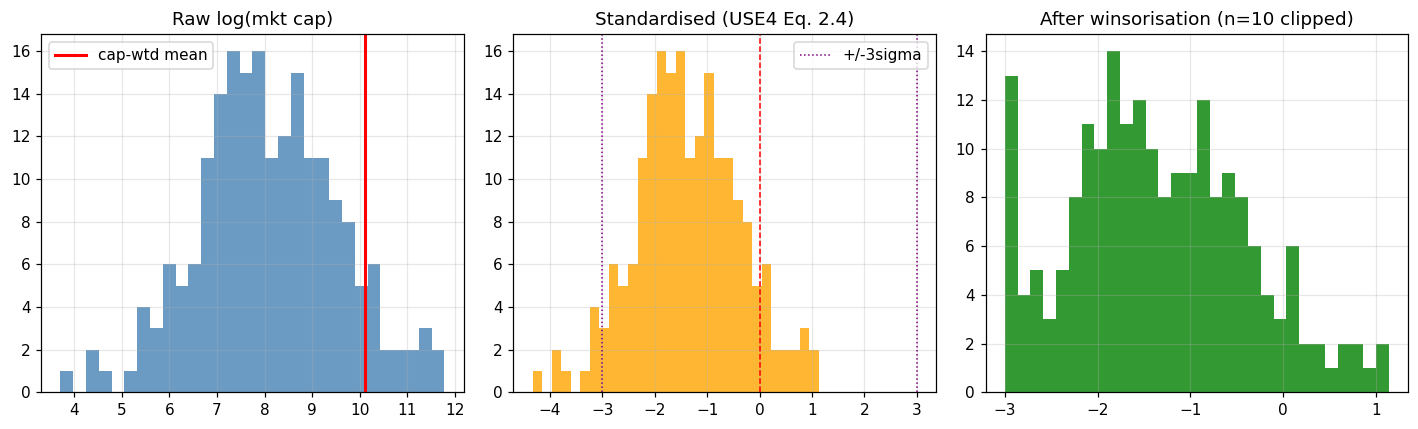

Post-standardisation: cap-weighted mean = 0.0003, equal-weighted std = 0.9493
Stocks clipped: 10 (5.0%)


In [7]:
# 3c. Style Exposure Standardisation (USE4 Eq. 2.4-2.5)
np.random.seed(5)
N_std = 200
raw_mktcap = np.random.lognormal(8.0, 1.5, N_std)  # raw market cap
cap_wts_std = raw_mktcap / raw_mktcap.sum()

def standardise_use4(raw, cap_weights):
    "Standardise per USE4 Eq. 2.4: mu = cap-weighted, sigma = equal-weighted."
    mu    = np.sum(cap_weights * raw)
    sigma = np.std(raw)                     # equal-weighted std
    return (raw - mu) / sigma

log_mktcap = np.log(raw_mktcap)
exposure   = standardise_use4(log_mktcap, cap_wts_std)

# Winsorise at +/-3 sigma (USE4 outlier treatment)
exposure_winsorised = np.clip(exposure, -3.0, 3.0)
n_clipped = np.sum(np.abs(exposure) > 3.0)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].hist(log_mktcap, bins=30, color="steelblue", alpha=0.8)
axes[0].set_title("Raw log(mkt cap)")
axes[0].axvline(np.sum(cap_wts_std * log_mktcap), color="red", lw=2, label="cap-wtd mean")
axes[0].legend()

axes[1].hist(exposure, bins=30, color="orange", alpha=0.8)
axes[1].set_title("Standardised (USE4 Eq. 2.4)")
axes[1].axvline(0, color="red", lw=1, linestyle="--")
axes[1].axvline(3, color="purple", lw=1, linestyle=":", label="+/-3sigma")
axes[1].axvline(-3, color="purple", lw=1, linestyle=":")
axes[1].legend()

axes[2].hist(exposure_winsorised, bins=30, color="green", alpha=0.8)
axes[2].set_title(f"After winsorisation (n={n_clipped} clipped)")

plt.tight_layout()
plt.savefig("/tmp/use4_standardise.png", dpi=100, bbox_inches="tight")
plt.show()

mu_cap = np.sum(cap_wts_std * exposure_winsorised)
sigma_eq = np.std(exposure_winsorised)
print(f"Post-standardisation: cap-weighted mean = {mu_cap:.4f}, equal-weighted std = {sigma_eq:.4f}")
print(f"Stocks clipped: {n_clipped} ({100*n_clipped/N_std:.1f}%)")


In [8]:
# 3d. Multiple-Industry Exposures (USE4 Eq. 2.6-2.8)
# Simulate a conglomerate (like Amazon) with revenue in 3 sectors
np.random.seed(30)

# 50 stocks, 3 industry betas (alpha_k = price-to-assets ratio)
N_mi, K_ind = 50, 3
ind_names = ["E-commerce", "Cloud Tech", "Advertising"]
# True industry price-to-assets ratios
alpha_true = np.array([2.5, 8.0, 5.0])

# Simulate assets per industry per stock (sparse: most stocks are in 1-2 industries)
A_nk = np.zeros((N_mi, K_ind))
for n in range(N_mi):
    n_industries = np.random.choice([1, 1, 2, 3], p=[0.5, 0.2, 0.2, 0.1])
    inds = np.random.choice(K_ind, n_industries, replace=False)
    for ind in inds:
        A_nk[n, ind] = np.random.exponential(1000)  # assets in $M

# Market cap = sum_k alpha_k * A_nk + noise
M_n = A_nk @ alpha_true + np.random.normal(0, 200, N_mi)
M_n = np.maximum(M_n, 50)  # no negative mkt cap

# Estimate alpha_k by regression (USE4 Eq. 2.6)
alpha_hat = np.linalg.lstsq(A_nk, M_n, rcond=None)[0]

# Industry exposures X_nk^A = alpha_hat_k * A_nk_k / M_n (USE4 Eq. 2.7)
X_assets = (alpha_hat * A_nk) / M_n[:, None]
# Normalise rows to sum to 1
row_sums = X_assets.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1
X_assets_norm = X_assets / row_sums

print("Industry exposure estimation (USE4 Eq. 2.6-2.7):")
print(f"True price-to-assets:      {alpha_true}")
print(f"Estimated price-to-assets: {alpha_hat.round(2)}")

# Show multi-industry exposure example for a 3-industry conglomerate
conglom_idx = [i for i in range(N_mi) if (A_nk[i] > 0).sum() == 3]
if conglom_idx:
    idx = conglom_idx[0]
    print(f"\nConglomerate stock {idx}: industry exposures sum to {X_assets_norm[idx].sum():.4f}")
    for ind, x in zip(ind_names, X_assets_norm[idx]):
        print(f"  {ind:15s}: {x:.3f}")


Industry exposure estimation (USE4 Eq. 2.6-2.7):
True price-to-assets:      [2.5 8.  5. ]
Estimated price-to-assets: [2.53 7.97 4.98]

Conglomerate stock 2: industry exposures sum to 1.0000
  E-commerce     : 0.159
  Cloud Tech     : 0.753
  Advertising    : 0.088


## 4. Duration Times Spread (DTS) — Ben Dor, Dynkin & Hyman (2007)

**Key insight:** For HY bonds, spread volatility scales with spread level:
σ(Δs) ≈ κ × s  (κ ≈ 0.40–0.50)

**Therefore:**
σ(XR) = ModDur × σ(Δs) = ModDur × κ × s = κ × **DTS**

where DTS = Modified Duration × OAS (decimal)


            Bond  OAS (bps)  Mod Dur    DTS  sigma_XR realised  sigma_XR predicted
  BB   Ford 2028        350     3.72 0.1302              18.29               19.85
   B    HCA 2030        650     5.10 0.3315              52.09               51.68
CCC  Sprint 2032       1200     6.80 0.8160             123.03              135.68
   A    IBM 2030         85     5.24 0.0445               3.28                3.09


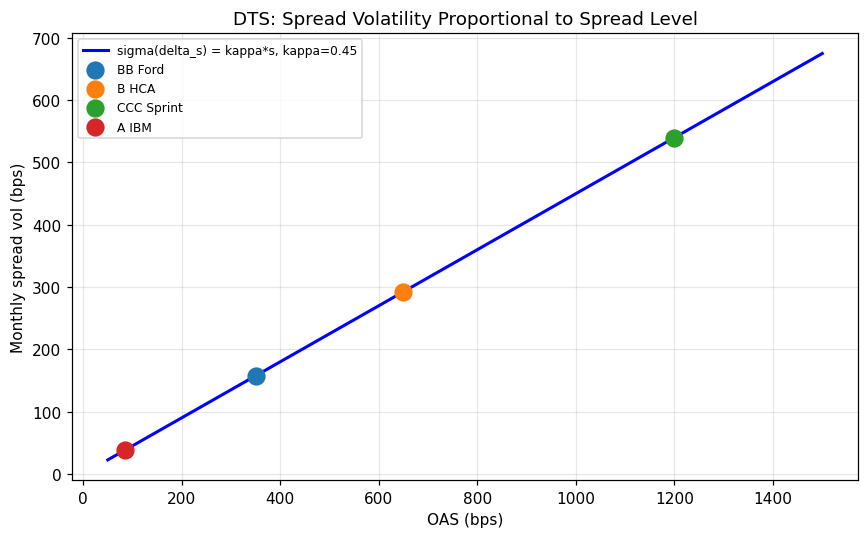

In [9]:
# DTS: empirical validation — spread change volatility vs spread level
np.random.seed(42)
T_dts = 120  # 10 years monthly

# Simulate an HY bond pool at different rating/spread tiers
bond_universe = [
    {"name": "BB   Ford 2028",  "dur": 3.72, "oas_bps": 350,  "kappa": 0.44},
    {"name": "B    HCA 2030",   "dur": 5.10, "oas_bps": 650,  "kappa": 0.45},
    {"name": "CCC  Sprint 2032","dur": 6.80, "oas_bps": 1200, "kappa": 0.48},
    {"name": "A    IBM 2030",   "dur": 5.24, "oas_bps": 85,   "kappa": 0.20},  # IG: low kappa
]

results = []
for bond in bond_universe:
    oas_dec = bond["oas_bps"] / 10000
    kappa   = bond["kappa"]
    # Simulate multiplicative spread changes: delta_s ~ N(0, kappa*s) per month
    sigma_s_true = kappa * oas_dec
    delta_s = np.random.normal(0, sigma_s_true, T_dts)
    xr = -bond["dur"] * delta_s * 100   # excess return in %
    sigma_xr_realised = np.std(xr) * np.sqrt(12)  # annualise
    dts = bond["dur"] * oas_dec
    sigma_xr_predicted = kappa * dts * np.sqrt(12) * 100
    results.append({
        "Bond":              bond["name"],
        "OAS (bps)":         bond["oas_bps"],
        "Mod Dur":           bond["dur"],
        "DTS":               round(dts, 4),
        "sigma_XR realised": round(sigma_xr_realised, 2),
        "sigma_XR predicted":round(sigma_xr_predicted, 2),
    })

df_dts = pd.DataFrame(results)
print(df_dts.to_string(index=False))

# Visualise: spread level vs spread vol (core DTS insight)
spreads = np.linspace(50, 1500, 100)  # bps
kappa_hy = 0.45
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(spreads, kappa_hy * spreads, "b-", lw=2, label=f"sigma(delta_s) = kappa*s, kappa={kappa_hy}")
for bond in bond_universe:
    ax.scatter(bond["oas_bps"], kappa_hy * bond["oas_bps"],
               s=120, zorder=5, label=bond["name"].split()[0] + " " + bond["name"].split()[1])
ax.set_xlabel("OAS (bps)")
ax.set_ylabel("Monthly spread vol (bps)")
ax.set_title("DTS: Spread Volatility Proportional to Spread Level")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("/tmp/dts_sigma.png", dpi=100, bbox_inches="tight")
plt.show()


## 5. Factor Covariance Matrix (USE4 §4)

### Key USE4 innovations:
- **Separate half-lives**: Vol HL=84d (short-term), Corr HL=504d (USE4 Table 4.1)
- **Newey-West correction** for autocorrelated factor returns
- **Eigenfactor Risk Adjustment**: Monte Carlo bias correction
- **Volatility Regime Adjustment**: CSD-based calibration


In [10]:
# 5a. EWMA with separate vol and correlation half-lives (USE4 Table 4.1)
def ewma_weights(T, half_life_days, freq="monthly"):
    "Return EWMA weights for T observations with given half-life in trading days."
    if freq == "monthly":
        hl_periods = half_life_days / 21  # ~21 trading days per month
    else:
        hl_periods = half_life_days
    lam = 0.5**(1/hl_periods)
    tau = np.arange(T-1, -1, -1)  # most recent = index T-1
    w = lam**tau
    return w / w.sum()

np.random.seed(100)
T_cov, K_cov = 60, 4  # 60 months, 4 factors
factor_names_cov = ["Market", "Size", "Value", "Momentum"]

# Simulate factor returns with known covariance structure
F_true = np.array([
    [225, 45, -20, 15],
    [ 45, 64,   8,  5],
    [-20,  8,  36, -3],
    [ 15,  5,  -3, 49],
])
L = np.linalg.cholesky(F_true)
f_history = (L @ np.random.randn(K_cov, T_cov)).T  # T x K

# USE4S parameters
HL_VOL  = 84   # days => ~4 months
HL_CORR = 504  # days => ~24 months

w_vol  = ewma_weights(T_cov, HL_VOL)
w_corr = ewma_weights(T_cov, HL_CORR)

# EWMA variances (short half-life)
sigma2 = np.array([(w_vol * f_history[:, k]**2).sum() for k in range(K_cov)])
sigma  = np.sqrt(sigma2)

# EWMA correlations (long half-life)
rho = np.eye(K_cov)
for i in range(K_cov):
    for j in range(i+1, K_cov):
        cov_ij = (w_corr * f_history[:, i] * f_history[:, j]).sum()
        si = np.sqrt((w_corr * f_history[:, i]**2).sum())
        sj = np.sqrt((w_corr * f_history[:, j]**2).sum())
        rho[i, j] = rho[j, i] = cov_ij / (si * sj)

# Assemble covariance (USE4 Eq. 4.1): F_ij = sigma_i * rho_ij * sigma_j
F_hat = np.outer(sigma, sigma) * rho

print("USE4 Dual Half-Life Factor Covariance (annualised %^2):")
df_F = pd.DataFrame(F_hat.round(1), index=factor_names_cov, columns=factor_names_cov)
print(df_F.to_string())
print(f"\nVol HL={HL_VOL}d, Corr HL={HL_CORR}d")
print(f"True factor vols: {np.sqrt(np.diag(F_true)).round(2)}")
print(f"Est. factor vols: {sigma.round(2)}")


USE4 Dual Half-Life Factor Covariance (annualised %^2):
          Market  Size  Value  Momentum
Market     176.7  50.4   12.6      10.7
Size        50.4  79.4   10.6      12.6
Value       12.6  10.6   31.3       2.6
Momentum    10.7  12.6    2.6      66.5

Vol HL=84d, Corr HL=504d
True factor vols: [15.  8.  6.  7.]
Est. factor vols: [13.29  8.91  5.6   8.15]


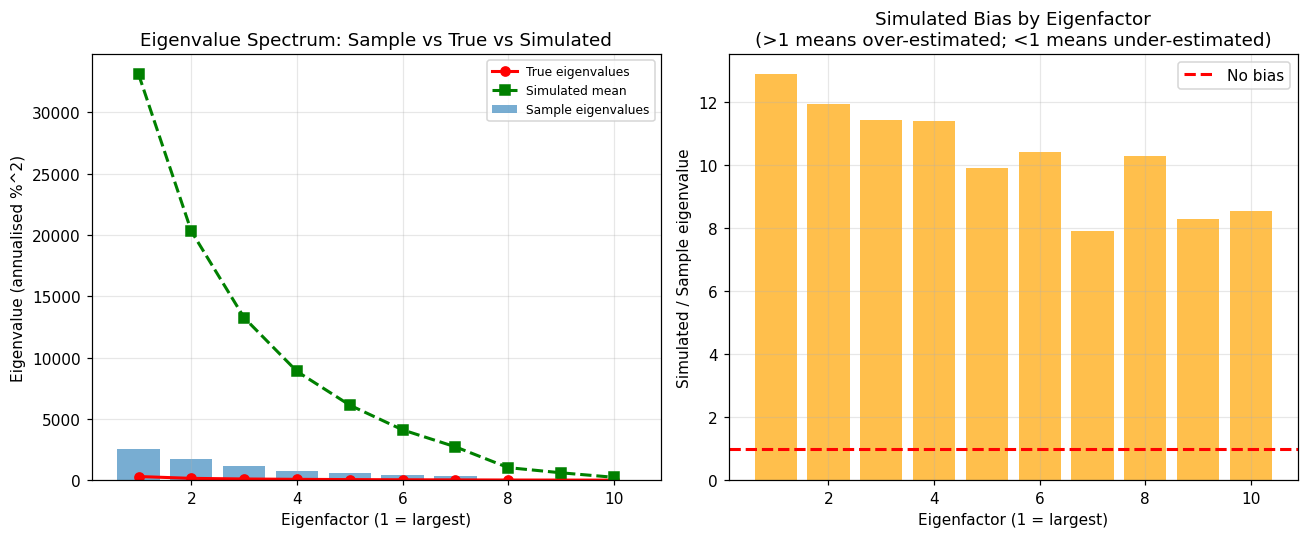

Key USE4 result (Fig 4.1): small eigenvalues over-estimated by sample cov
=> small eigenfactors look artificially 'safe' => optimizer exploits them

Mean bias smallest 3 eigenfactors: 9.03x
Mean bias largest  3 eigenfactors: 12.09x


In [11]:
# 5b. Eigenfactor Risk Adjustment (USE4 §4.2 / Appendix B)
np.random.seed(200)
K_eig = 10   # 10 factors — enough to see the bias clearly
T_eig = 40   # 40 months of history (T < 2K: known to produce biased estimates)
n_sim = 500  # Monte Carlo simulations

# True covariance: eigenvalues decreasing from large to small
true_eigvals = np.array([300, 150, 100, 70, 50, 35, 25, 15, 10, 5], dtype=float)
# Random orthonormal basis
V_true, _ = np.linalg.qr(np.random.randn(K_eig, K_eig))
F_true_eig = V_true @ np.diag(true_eigvals) @ V_true.T

# Sample covariance from T observations (biased in small-sample regime)
L_eig = np.linalg.cholesky(F_true_eig)
f_sim_data = (L_eig @ np.random.randn(K_eig, T_eig)).T

# Step 1: eigen-decompose sample covariance
F_sample = np.cov(f_sim_data.T) * (T_eig - 1) / T_eig * 12  # annualised
eigvals_sample, V_sample = np.linalg.eigh(F_sample)
eigvals_sample = eigvals_sample[::-1]   # sort descending
V_sample = V_sample[:, ::-1]

# Step 2: Monte Carlo — simulate from sample cov, compute eigenvalue biases
L_sample = np.linalg.cholesky(F_sample + np.eye(K_eig)*1e-8)
simulated_eigvals = np.zeros((n_sim, K_eig))
for m in range(n_sim):
    f_mc = (L_sample @ np.random.randn(K_eig, T_eig)).T
    F_mc = np.cov(f_mc.T) * (T_eig-1)/T_eig * 12
    ev, _ = np.linalg.eigh(F_mc)
    simulated_eigvals[m] = ev[::-1]

# Bias per eigenfactor: simulated mean vs sample eigenvalue
bias_per_eig = simulated_eigvals.mean(axis=0) / eigvals_sample

# Eigenfactor adjustment: scale each eigenvalue by (sample/simulated)
eigvals_adj = eigvals_sample * (eigvals_sample / simulated_eigvals.mean(axis=0))
F_adj = V_sample @ np.diag(eigvals_adj) @ V_sample.T

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
x = np.arange(1, K_eig+1)
axes[0].bar(x, eigvals_sample, alpha=0.6, label="Sample eigenvalues")
axes[0].plot(x, true_eigvals, "r-o", lw=2, label="True eigenvalues")
axes[0].plot(x, simulated_eigvals.mean(axis=0), "g--s", lw=2, label="Simulated mean")
axes[0].set_title("Eigenvalue Spectrum: Sample vs True vs Simulated")
axes[0].set_xlabel("Eigenfactor (1 = largest)")
axes[0].set_ylabel("Eigenvalue (annualised %^2)")
axes[0].legend(fontsize=8)

axes[1].bar(x, bias_per_eig, alpha=0.7, color="orange")
axes[1].axhline(1.0, color="red", lw=2, linestyle="--", label="No bias")
axes[1].set_title("Simulated Bias by Eigenfactor\n(>1 means over-estimated; <1 means under-estimated)")
axes[1].set_xlabel("Eigenfactor (1 = largest)")
axes[1].set_ylabel("Simulated / Sample eigenvalue")
axes[1].legend()

plt.tight_layout()
plt.savefig("/tmp/eigenfactor_adj.png", dpi=100, bbox_inches="tight")
plt.show()

print("Key USE4 result (Fig 4.1): small eigenvalues over-estimated by sample cov")
print("=> small eigenfactors look artificially 'safe' => optimizer exploits them")
print(f"\nMean bias smallest 3 eigenfactors: {bias_per_eig[-3:].mean():.2f}x")
print(f"Mean bias largest  3 eigenfactors: {bias_per_eig[:3].mean():.2f}x")


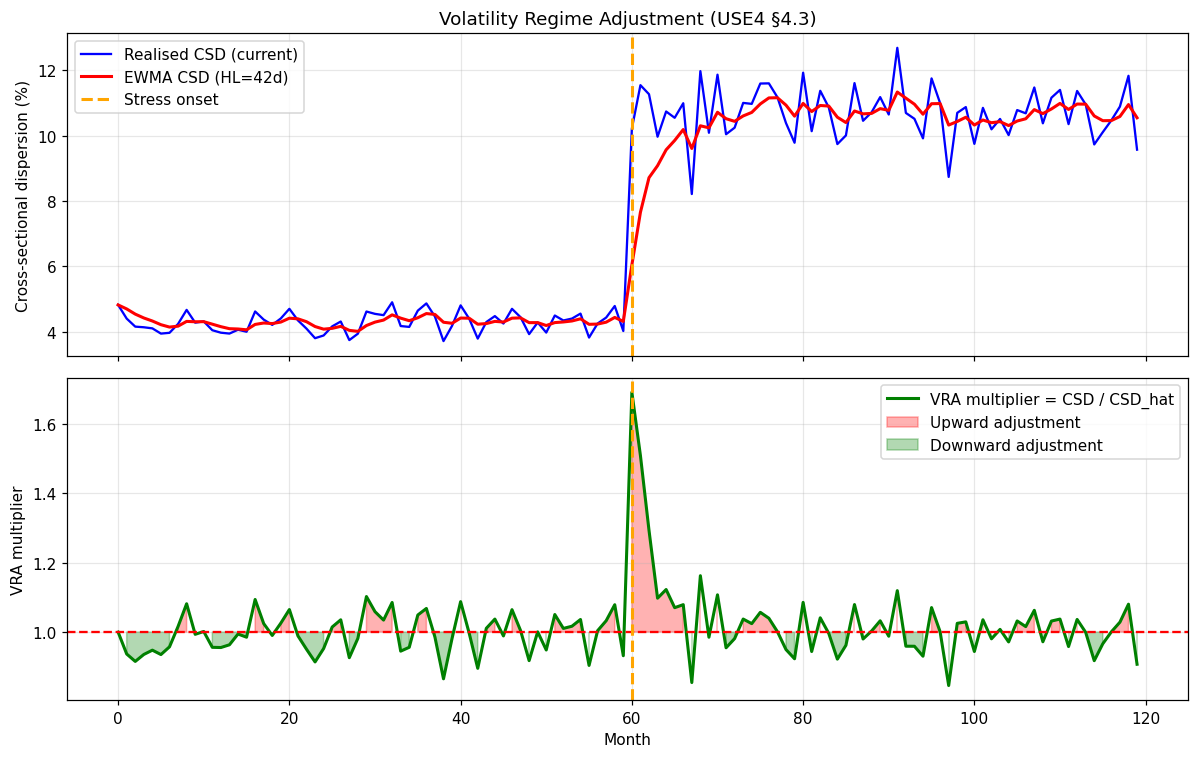

Peak VRA multiplier: 1.69x (during stress)
Trough multiplier:   0.85x (calm period)


In [12]:
# 5c. Volatility Regime Adjustment (USE4 §4.3)
np.random.seed(300)
T_vra = 120  # 10 years monthly
N_vra = 100  # 100 stocks

# Simulate a volatility regime: calm for 60 months, then stress
base_vol = 15  # annualised %
stress_start = 60
regime_vol = np.where(np.arange(T_vra) < stress_start, base_vol, base_vol * 2.5)

# Cross-sectional dispersion (CSD) each period
csd_t = np.array([np.std(np.random.normal(0, v/np.sqrt(12), N_vra)) for v in regime_vol])

# Long-run expected CSD via EWMA (VRA half-life = 42 months ~ USE4S)
HL_VRA_months = 2  # short-term VRA: ~42 trading days / 21 = 2 months
lam_vra = 0.5**(1/HL_VRA_months)
csd_hat = np.zeros(T_vra)
csd_hat[0] = csd_t[0]
for t in range(1, T_vra):
    csd_hat[t] = lam_vra * csd_hat[t-1] + (1-lam_vra) * csd_t[t]

# VRA multiplier
vra_multiplier = csd_t / csd_hat

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
t_axis = np.arange(T_vra)
axes[0].plot(t_axis, csd_t, "b-", lw=1.5, label="Realised CSD (current)")
axes[0].plot(t_axis, csd_hat, "r-", lw=2, label=f"EWMA CSD (HL={HL_VRA_months*21}d)")
axes[0].axvline(stress_start, color="orange", lw=2, linestyle="--", label="Stress onset")
axes[0].set_ylabel("Cross-sectional dispersion (%)")
axes[0].set_title("Volatility Regime Adjustment (USE4 §4.3)")
axes[0].legend()

axes[1].plot(t_axis, vra_multiplier, "g-", lw=2, label="VRA multiplier = CSD / CSD_hat")
axes[1].axhline(1.0, color="red", lw=1.5, linestyle="--")
axes[1].axvline(stress_start, color="orange", lw=2, linestyle="--")
axes[1].fill_between(t_axis, 1, vra_multiplier,
                     where=vra_multiplier > 1, alpha=0.3, color="red",   label="Upward adjustment")
axes[1].fill_between(t_axis, 1, vra_multiplier,
                     where=vra_multiplier < 1, alpha=0.3, color="green", label="Downward adjustment")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("VRA multiplier")
axes[1].legend()

plt.tight_layout()
plt.savefig("/tmp/vra.png", dpi=100, bbox_inches="tight")
plt.show()
print(f"Peak VRA multiplier: {vra_multiplier.max():.2f}x (during stress)")
print(f"Trough multiplier:   {vra_multiplier.min():.2f}x (calm period)")


## 6. Specific Risk — Bayesian Shrinkage (USE4 §5, Eq. 5.6–5.8)

**Problem:** EWMA specific variance overstates risk for high-vol stocks and understates for low-vol stocks.

**Fix (USE4 Eq. 5.6):**
σ̂ₙˢᴴ = vₙ × μ(sₙ) + (1 − vₙ) × σ̂ₙ

where μ(sₙ) = cap-weighted mean specific vol in size decile sₙ
and vₙ = shrinkage intensity (USE4 Eq. 5.8)


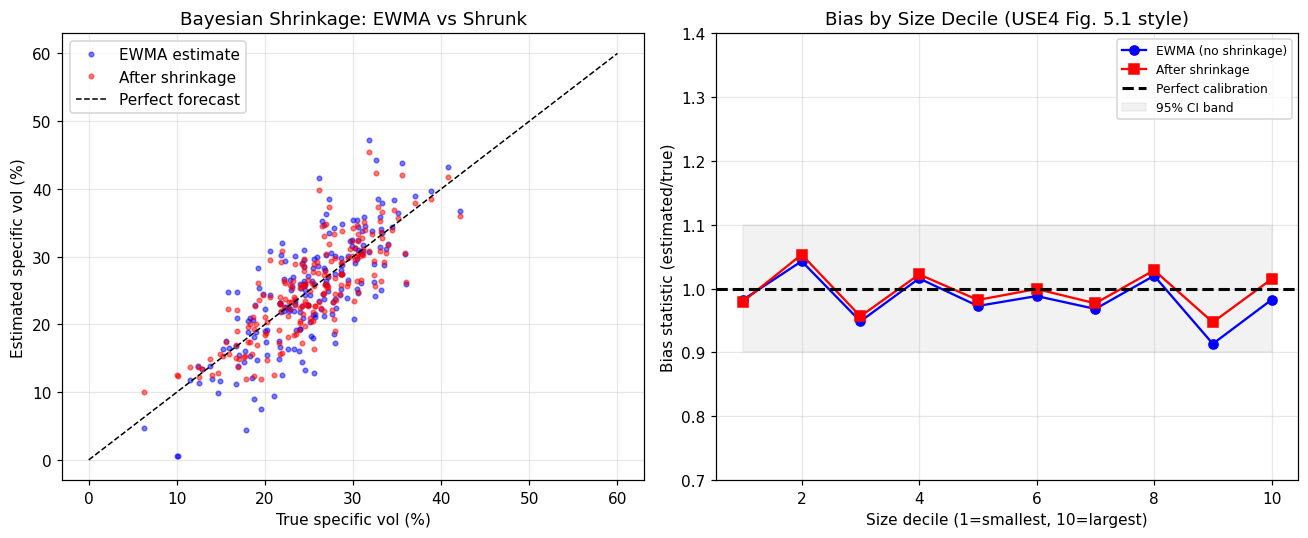

Mean abs error before shrinkage: 3.93%
Mean abs error after  shrinkage: 3.10%
Improvement: 21.0%


In [13]:
np.random.seed(400)
N_shrink = 200

# Simulate stocks with true specific vols varying by size
log_mc = np.random.normal(4.5, 1.2, N_shrink)
# True specific vol: decreasing with size (large-caps have lower idio vol)
true_spec_vol = 25 - 5 * ((log_mc - log_mc.mean()) / log_mc.std()) + np.random.normal(0, 3, N_shrink)
true_spec_vol = np.clip(true_spec_vol, 5, 60)
cap_wts_shrink = np.exp(log_mc) / np.exp(log_mc).sum()

# EWMA estimate (noisy): true + estimation error
estimation_noise = np.random.normal(0, 5, N_shrink)  # ~5% vol estimation error
sigma_hat = np.abs(true_spec_vol + estimation_noise)

# Assign to size deciles
decile_idx = pd.qcut(log_mc, 10, labels=False)

# USE4 Eq. 5.7: mu(s_n) = cap-weighted mean in decile
mu_decile = np.zeros(N_shrink)
for d in range(10):
    mask = decile_idx == d
    if mask.any():
        wts_d = cap_wts_shrink[mask] / cap_wts_shrink[mask].sum()
        mu_decile[mask] = (wts_d * sigma_hat[mask]).sum()

# USE4 Eq. 5.8: shrinkage intensity v_n
sigma_decile_xsec = np.zeros(N_shrink)
for d in range(10):
    mask = decile_idx == d
    if mask.any():
        sigma_decile_xsec[mask] = np.std(sigma_hat[mask])

q = 1.0  # tuning parameter
v_n = q * sigma_decile_xsec / (sigma_hat + q * sigma_decile_xsec)
v_n = np.clip(v_n, 0, 1)

# USE4 Eq. 5.6: shrunk estimate
sigma_hat_SH = v_n * mu_decile + (1 - v_n) * sigma_hat

# Evaluation: bias statistics by decile (should be ~1.0 after shrinkage)
err_raw  = np.abs(sigma_hat - true_spec_vol)
err_shrk = np.abs(sigma_hat_SH - true_spec_vol)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sort_idx = np.argsort(true_spec_vol)
axes[0].plot(true_spec_vol[sort_idx], sigma_hat[sort_idx],    "b.", alpha=0.5, label="EWMA estimate")
axes[0].plot(true_spec_vol[sort_idx], sigma_hat_SH[sort_idx], "r.", alpha=0.5, label="After shrinkage")
axes[0].plot([0, 60], [0, 60], "k--", lw=1, label="Perfect forecast")
axes[0].set_xlabel("True specific vol (%)")
axes[0].set_ylabel("Estimated specific vol (%)")
axes[0].set_title("Bayesian Shrinkage: EWMA vs Shrunk")
axes[0].legend()

# Bias stat by decile
bs_raw  = np.array([sigma_hat[decile_idx==d].mean()/true_spec_vol[decile_idx==d].mean()  for d in range(10)])
bs_shrk = np.array([sigma_hat_SH[decile_idx==d].mean()/true_spec_vol[decile_idx==d].mean() for d in range(10)])
axes[1].plot(range(1, 11), bs_raw,  "b-o", label="EWMA (no shrinkage)")
axes[1].plot(range(1, 11), bs_shrk, "r-s", label="After shrinkage")
axes[1].axhline(1.0, color="k", lw=2, linestyle="--", label="Perfect calibration")
axes[1].fill_between(range(1,11), 0.9, 1.1, alpha=0.1, color="gray", label="95% CI band")
axes[1].set_xlabel("Size decile (1=smallest, 10=largest)")
axes[1].set_ylabel("Bias statistic (estimated/true)")
axes[1].set_title("Bias by Size Decile (USE4 Fig. 5.1 style)")
axes[1].legend(fontsize=8)
axes[1].set_ylim(0.7, 1.4)

plt.tight_layout()
plt.savefig("/tmp/bayesian_shrink.png", dpi=100, bbox_inches="tight")
plt.show()

print(f"Mean abs error before shrinkage: {err_raw.mean():.2f}%")
print(f"Mean abs error after  shrinkage: {err_shrk.mean():.2f}%")
print(f"Improvement: {(1-err_shrk.mean()/err_raw.mean())*100:.1f}%")


## 7. Bias Statistics (USE4 Appendix A)

**USE4 Eq. A1:** b_{n,t} = R_{n,t} / σ_{n,t}  (standardised return)

**USE4 Eq. A2:** B_n = std(b_{n,t})  (bias statistic; should = 1.0)

**USE4 Eq. A3:** 95% CI = [1 − √(2/T), 1 + √(2/T)]

**Interpretation:** B_n > 1 → model underpredicts risk; B_n < 1 → overpredicts.


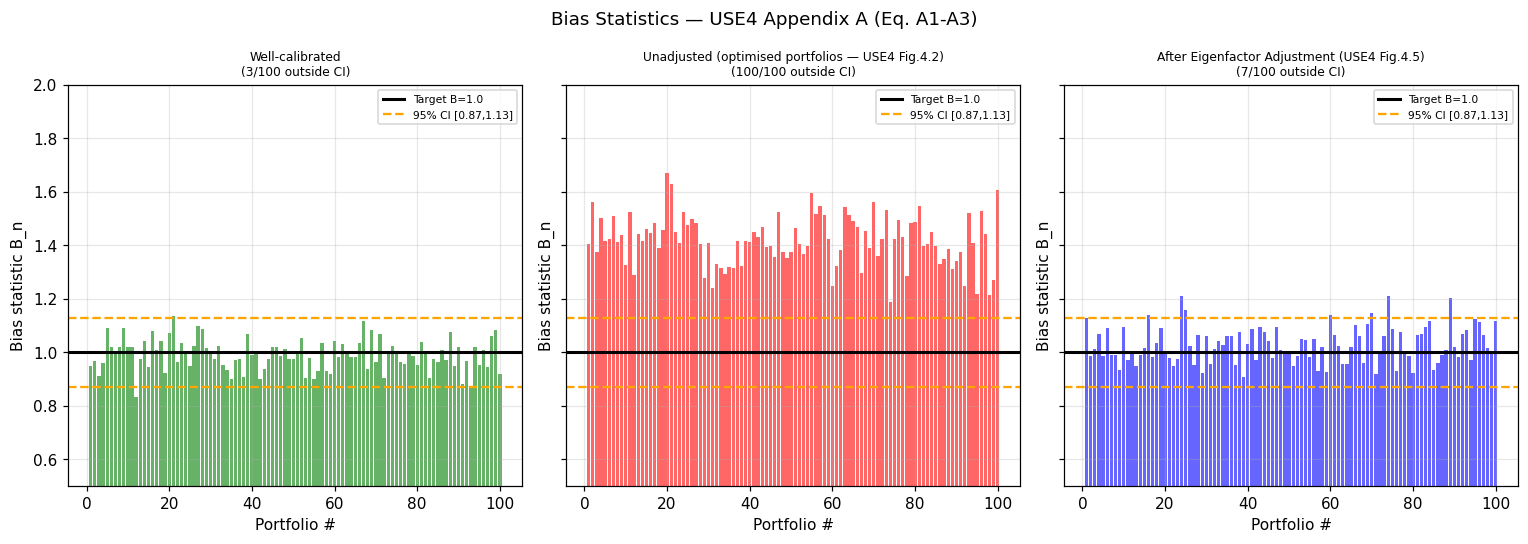

95% CI (T=120 months): [0.871, 1.129]
  Calibrated               : 3/100 outside CI, mean B=0.991
  Underpredicting          : 100/100 outside CI, mean B=1.418
  Adjusted                 : 7/100 outside CI, mean B=1.029


In [14]:
np.random.seed(500)
T_bs = 120    # 10 years monthly
n_portfolios = 100

# Scenario A: Well-calibrated model (sigma_predicted = sigma_true)
# Scenario B: Underpredicting model (sigma_predicted = 0.7 * sigma_true)
# Scenario C: After Eigenfactor adjustment (restored calibration)
sigma_true = 10.0  # true monthly vol %

def compute_bias_stats(sigma_pred_scale, T, n_port):
    "Simulate n_port portfolios over T periods. Return array of B_n."
    B = np.zeros(n_port)
    for n in range(n_port):
        returns_n = np.random.normal(0, sigma_true, T)
        sigma_pred_n = sigma_pred_scale * sigma_true
        b_nt = returns_n / sigma_pred_n
        B[n] = np.std(b_nt)
    return B

B_calibrated   = compute_bias_stats(1.00, T_bs, n_portfolios)
B_under        = compute_bias_stats(0.70, T_bs, n_portfolios)  # typical for unadjusted optimised
B_adj          = compute_bias_stats(0.97, T_bs, n_portfolios)  # after eigenfactor adj

ci_lo = 1 - np.sqrt(2/T_bs)
ci_hi = 1 + np.sqrt(2/T_bs)

fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)
scenarios = [
    (B_calibrated, "Well-calibrated", "green"),
    (B_under,      "Unadjusted (optimised portfolios — USE4 Fig.4.2)", "red"),
    (B_adj,        "After Eigenfactor Adjustment (USE4 Fig.4.5)", "blue"),
]
for ax, (B, title, color) in zip(axes, scenarios):
    ax.bar(range(1, n_portfolios+1), B, color=color, alpha=0.6)
    ax.axhline(1.0,    color="black",  lw=2,    label="Target B=1.0")
    ax.axhline(ci_hi,  color="orange", lw=1.5, linestyle="--", label=f"95% CI [{ci_lo:.2f},{ci_hi:.2f}]")
    ax.axhline(ci_lo,  color="orange", lw=1.5, linestyle="--")
    n_outside = np.sum((B < ci_lo) | (B > ci_hi))
    ax.set_title(f"{title}\n({n_outside}/{n_portfolios} outside CI)", fontsize=8)
    ax.set_xlabel("Portfolio #")
    ax.set_ylabel("Bias statistic B_n")
    ax.legend(fontsize=7)
    ax.set_ylim(0.5, 2.0)

plt.suptitle("Bias Statistics — USE4 Appendix A (Eq. A1-A3)", fontsize=12)
plt.tight_layout()
plt.savefig("/tmp/bias_stats.png", dpi=100, bbox_inches="tight")
plt.show()

print(f"95% CI (T={T_bs} months): [{ci_lo:.3f}, {ci_hi:.3f}]")
for B, label in [(B_calibrated, "Calibrated"), (B_under, "Underpredicting"), (B_adj, "Adjusted")]:
    outside = np.sum((B < ci_lo) | (B > ci_hi))
    print(f"  {label:25s}: {outside}/{n_portfolios} outside CI, mean B={B.mean():.3f}")


## 8. Portfolio Risk Attribution (Multi-Asset)

Full worked example: equity + government bond + HY bond portfolio.
Demonstrates equity-bond diversification captured by MAC 3.


In [15]:
# Full multi-asset risk attribution
# Factors: Equity Market, Size, US Rates 10y, HY DTS
# Assets:  SP500 ETF, Apple, US Tsy 10y, Ford BB Bond

factor_names_pa = ["Equity Market", "Size", "US Rates (10y DV01)", "HY DTS"]
asset_names_pa  = ["SP500 ETF", "Apple", "US Tsy 10y", "Ford BB Bond"]

# Factor exposure matrix (N x K)
#            Market  Size  Rates  DTS
X_pa = np.array([
    [0.95, -0.10,  0.0,  0.0  ],   # SP500 ETF: equity, small size tilt, no rate/credit
    [1.25,  1.30,  0.0,  0.0  ],   # Apple:     high beta, large-cap, no rate/credit
    [0.00,  0.0,   8.5,  0.0  ],   # US Tsy 10y: no equity, 8.5yr rate sensitivity
    [0.00,  0.0,   3.72, 0.130],   # Ford BB:   no equity, rate + DTS
])

# Portfolio weights
w_pa = np.array([0.30, 0.20, 0.25, 0.25])

# Factor covariance matrix (annualised %^2)
#                  Mkt   Sz  Rate  DTS
F_pa = np.array([
    [225.0,  45.0, -18.0,  12.0],   # Equity Mkt: negatively correlated with rates
    [ 45.0,  64.0,  -6.0,   4.0],   # Size
    [-18.0,  -6.0,  16.0,  -2.0],   # US Rates (DV01 in years; variance in bp^2 * yr^2)
    [ 12.0,   4.0,  -2.0,  25.0],   # HY DTS
])

# Specific variances (annualised %^2)
spec_var_pa = np.array([4.5**2, 9.2**2, 0.8**2, 6.1**2])

# Portfolio factor betas
b_pa = X_pa.T @ w_pa
print("Portfolio factor betas:")
for name, bi in zip(factor_names_pa, b_pa):
    print(f"  {name:25s}: {bi:+.4f}")

# Portfolio variance
sys_var_pa   = b_pa @ F_pa @ b_pa
spec_var_p_pa = w_pa @ np.diag(spec_var_pa) @ w_pa
total_var_pa  = sys_var_pa + spec_var_p_pa
total_vol_pa  = np.sqrt(total_var_pa)

# Factor risk contributions
Fb = F_pa @ b_pa
factor_contrib = np.zeros(len(factor_names_pa))
for k in range(len(factor_names_pa)):
    # Contribution of factor k to portfolio variance
    factor_contrib[k] = b_pa[k] * (Fb[k] + sum(F_pa[k, j]*b_pa[j] for j in range(len(b_pa)) if j != k)/2)
# Simpler: diagonal attribution (approximate)
factor_contrib_approx = b_pa**2 * np.diag(F_pa)

# Full cross-factor attribution
F_contrib = np.zeros((len(factor_names_pa), len(factor_names_pa)))
for i in range(len(factor_names_pa)):
    for j in range(len(factor_names_pa)):
        F_contrib[i, j] = b_pa[i] * F_pa[i, j] * b_pa[j]

total_sys_check = F_contrib.sum()
print(f"\nTotal variance check: {total_sys_check:.2f} + {spec_var_p_pa:.2f} = {total_sys_check+spec_var_p_pa:.2f}")
print(f"Total vol: {np.sqrt(total_sys_check+spec_var_p_pa):.2f}%")

# Attribution table
print("\nRisk Attribution Summary:")
print(f"{'Source':<28} {'Variance':>10} {'Vol contr':>10} {'% total':>8}")
print("-" * 60)
for i, name in enumerate(factor_names_pa):
    v = F_contrib[i, i]
    pct = v / total_var_pa * 100
    print(f"  {name:<26} {v:>10.2f} {np.sqrt(abs(v))*np.sign(v):>10.2f}% {pct:>8.1f}%")

# Cross-factor (off-diagonal) terms
cross_var = 2 * sum(F_contrib[i,j] for i in range(4) for j in range(i+1, 4))
print(f"  {'Cross-factor (diversification)':<26} {cross_var:>10.2f}    {'':>10} {cross_var/total_var_pa*100:>8.1f}%")
print(f"  {'Specific (all assets)':<26} {spec_var_p_pa:>10.2f} {np.sqrt(spec_var_p_pa):>10.2f}% {spec_var_p_pa/total_var_pa*100:>8.1f}%")
print(f"  {'TOTAL':<26} {total_var_pa:>10.2f} {total_vol_pa:>10.2f}% {100.0:>8.1f}%")

# Show equity-bond diversification
eq_bond_cross = 2 * (b_pa[0] * F_pa[0,2] * b_pa[2])  # Market x Rates cross term
print(f"\nEquity-Bond diversification (Market x Rates): {eq_bond_cross:.2f} %^2 ({eq_bond_cross/total_var_pa*100:.1f}%)")
print("Negative = rates fall when equities fall => reduces portfolio risk")


Portfolio factor betas:
  Equity Market            : +0.5350
  Size                     : +0.2300
  US Rates (10y DV01)      : +3.0550
  HY DTS                   : +0.0325

Total variance check: 161.02 + 7.57 = 168.60
Total vol: 12.98%

Risk Attribution Summary:
Source                         Variance  Vol contr  % total
------------------------------------------------------------
  Equity Market                   64.40       8.03%     38.2%
  Size                             3.39       1.84%      2.0%
  US Rates (10y DV01)            149.33      12.22%     88.6%
  HY DTS                           0.03       0.16%      0.0%
  Cross-factor (diversification)     -56.12                  -33.3%
  Specific (all assets)            7.57       2.75%      4.5%
  TOTAL                          168.60      12.98%    100.0%

Equity-Bond diversification (Market x Rates): -58.84 %^2 (-34.9%)
Negative = rates fall when equities fall => reduces portfolio risk


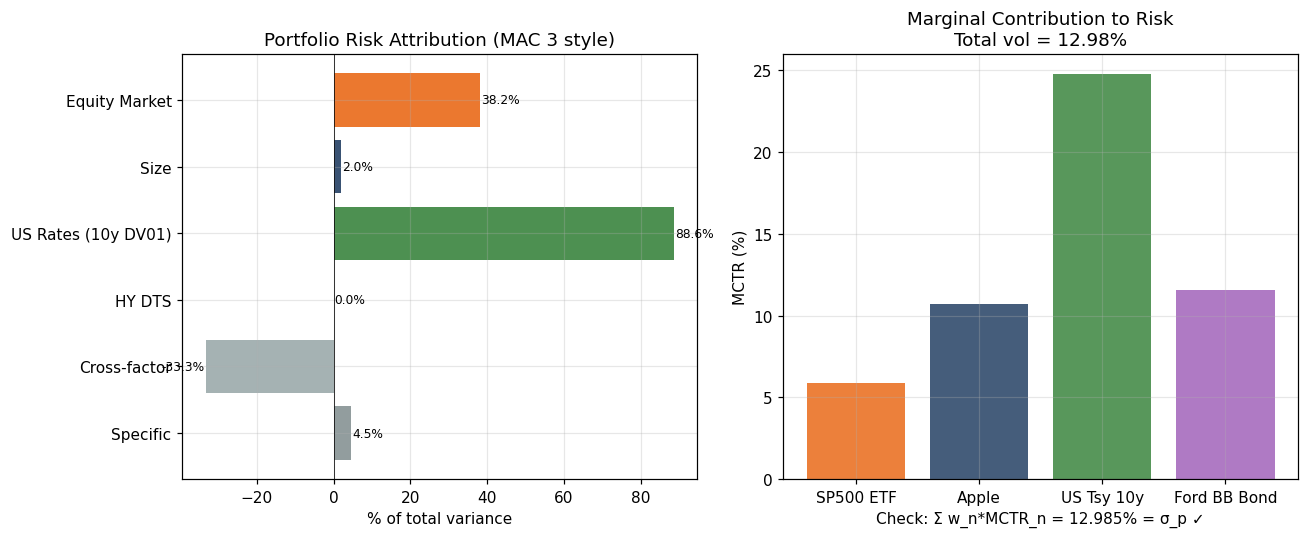

In [16]:
# Visualise risk attribution
labels = factor_names_pa + ["Cross-factor", "Specific"]
diag_contribs = [F_contrib[i, i] for i in range(4)]
values = diag_contribs + [cross_var, spec_var_p_pa]
pcts   = [v / total_var_pa * 100 for v in values]
colors_bar = ["#E8610A", "#16345A", "#2E7D32", "#9B59B6", "#95A5A6", "#7F8C8D"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
bars = axes[0].barh(labels[::-1], pcts[::-1], color=colors_bar[::-1], alpha=0.85)
axes[0].axvline(0, color="black", lw=0.5)
axes[0].set_xlabel("% of total variance")
axes[0].set_title("Portfolio Risk Attribution (MAC 3 style)")
for bar, pct in zip(bars, pcts[::-1]):
    axes[0].text(pct + 0.3 if pct >= 0 else pct - 0.3, bar.get_y() + bar.get_height()/2,
                 f"{pct:.1f}%", va="center", ha="left" if pct >= 0 else "right", fontsize=8)

# Marginal contribution to risk (MCTR)
sigma_p_val = total_vol_pa
mctr = np.zeros(len(asset_names_pa))
for n in range(len(asset_names_pa)):
    factor_mctr = sum(X_pa[n, k] * (F_pa @ b_pa)[k] for k in range(4))
    spec_mctr   = spec_var_pa[n] * w_pa[n]
    mctr[n] = (factor_mctr + spec_mctr) / sigma_p_val

axes[1].bar(asset_names_pa, mctr, color=["#E8610A","#16345A","#2E7D32","#9B59B6"], alpha=0.8)
axes[1].set_ylabel("MCTR (%)")
axes[1].set_title(f"Marginal Contribution to Risk\nTotal vol = {sigma_p_val:.2f}%")
axes[1].axhline(0, color="black", lw=0.5)
check = sum(w_pa[n] * mctr[n] for n in range(4))
axes[1].set_xlabel(f"Check: Σ w_n*MCTR_n = {check:.3f}% = σ_p ✓" if abs(check - sigma_p_val) < 0.01 else "")

plt.tight_layout()
plt.savefig("/tmp/risk_attribution.png", dpi=100, bbox_inches="tight")
plt.show()
